# Figura tipo 1C multi-referencia para muestras metagenómicas de *Saccharomyces*

Este notebook analiza las tablas `*.10kb_similarity.csv` generadas por tu pipeline de ventanas de 10 kb.

La lógica general es:

```text
BAM filtrado + VCF filtrado
↓
ventanas de 10 kb
↓
N_sites, SNPs_d, divergence, similarity
↓
figuras y resúmenes por referencia/muestra
```

La métrica `similarity_N_over_dplus1` está inspirada en la Figura 1C del artículo *High-Resolution Mapping of Complex Traits with a Four-Parent Advanced Intercross Yeast Population*:

```text
similarity = N / (d + 1)
```

donde:

- `N` = número de sitios comparables en una ventana
- `d` = número de diferencias de un solo nucleótido

En tu adaptación:

- cada muestra metagenómica se compara contra varias referencias
- cada referencia se analiza por separado
- los resultados se resumen por ventana, por cromosoma, por muestra y por referencia

## 1. Instalar librerías

Este notebook usa:

- `pandas` para leer y resumir tablas
- `matplotlib` para hacer figuras

En Colab normalmente ya están instaladas, pero esta celda asegura que estén disponibles.

In [1]:
!pip -q install pandas matplotlib

## 2. Conectar Google Drive

Colab no puede leer directamente los archivos de tu cluster.  
Por eso, los resultados de `results_by_ref/` deben estar copiados a Google Drive.

Estructura esperada:

```text
MyDrive/yeast/results_by_ref/
├── AAR/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
├── ADE/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
└── ...
```

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ls drive/MyDrive/yeast/results_by_ref/

AAR/  sake/  scer/  SGD_2010/  ZP568s1/


## 3. Configuración general

Edita estas rutas si tus resultados están en otra carpeta.

Parámetros importantes:

- `RESULTS_ROOT`: carpeta principal con resultados separados por referencia
- `OUTPUT_DIR`: carpeta donde se guardarán figuras y tablas resumen
- `MIN_N_SITES`: mínimo de sitios comparables por ventana
- `MAX_SAMPLES_TO_PLOT`: limita cuántas muestras se grafican para evitar figuras saturadas

In [4]:
import os
import glob
import re

import pandas as pd
import matplotlib.pyplot as plt

# Carpeta con resultados por referencia
RESULTS_ROOT = '/content/drive/MyDrive/yeast/results_by_ref'

# Carpeta de salida para figuras y tablas resumen
OUTPUT_DIR = '/content/drive/MyDrive/yeast/figures_1C_multi_ref'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Filtro mínimo de sitios comparables por ventana
MIN_N_SITES = 10

# Si tienes muchas muestras, puedes limitar el número graficado.
# Usa None para graficar todas.
MAX_SAMPLES_TO_PLOT = None

print('RESULTS_ROOT:', RESULTS_ROOT)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('MIN_N_SITES:', MIN_N_SITES)
print('MAX_SAMPLES_TO_PLOT:', MAX_SAMPLES_TO_PLOT)

RESULTS_ROOT: /content/drive/MyDrive/yeast/results_by_ref
OUTPUT_DIR: /content/drive/MyDrive/yeast/figures_1C_multi_ref
MIN_N_SITES: 10
MAX_SAMPLES_TO_PLOT: None


## 4. Detectar referencias disponibles

Cada subcarpeta dentro de `RESULTS_ROOT` se interpreta como una referencia.

Ejemplo:

```text
results_by_ref/AAR/
results_by_ref/ADE/
results_by_ref/SGD_2010/
```

El nombre de la carpeta se usa como nombre de referencia.

In [5]:
ref_dirs = sorted([
    d for d in glob.glob(os.path.join(RESULTS_ROOT, '*'))
    if os.path.isdir(d)
])

references = [os.path.basename(d) for d in ref_dirs]

print(f'Referencias encontradas: {len(references)}')
print(references)

Referencias encontradas: 5
['AAR', 'SGD_2010', 'ZP568s1', 'sake', 'scer']


In [6]:
ls $RESULTS_ROOT/SGD_2010/windows_10kb

Scerevisiae_10pct_NO.10kb_similarity.csv
Scerevisiae_window_mutated_10pct.10kb_similarity.csv


## 5. Funciones auxiliares

Estas funciones hacen tres cosas:

1. ordenar cromosomas correctamente (`chr1`, `chr2`, ..., `chr16`)
2. cargar todas las tablas de una referencia
3. preparar los datos para análisis y figuras

Columnas esperadas en cada CSV:

- `sample`
- `chrom`
- `start`
- `end`
- `N_sites`
- `SNPs_d`
- `divergence_d_over_N`
- `similarity_N_over_dplus1`

Significado:

- `N_sites`: posiciones comparables dentro de una ventana
- `SNPs_d`: SNPs detectados en esa ventana
- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: sitios comparables por diferencia, inspirado en la Figura 1C

In [7]:
def natural_chr_key(chrom):
    # Ordena cromosomas de forma biológica.
    # Funciona con nombres como chr1, chr10, chr1_AAR, chr12_ADE, chrI, chrII.
    chrom = str(chrom)

    # Caso numérico: chr1, chr2, chr10, chr1_AAR
    match = re.search(r'chr(\d+)', chrom, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Caso romano: chrI, chrII, chrXVI
    c = chrom.replace('chr', '').replace('Chr', '').split('_')[0]
    roman_map = {
        'I': 1, 'II': 2, 'III': 3, 'IV': 4,
        'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8,
        'IX': 9, 'X': 10, 'XI': 11, 'XII': 12,
        'XIII': 13, 'XIV': 14, 'XV': 15, 'XVI': 16
    }

    if c in roman_map:
        return roman_map[c]

    # Si no reconoce el formato, lo manda al final
    return 999


def load_reference_tables(ref_name):
    # Carga todos los CSV de ventanas de 10 kb para una referencia.
    #
    # Busca archivos en:
    # RESULTS_ROOT/ref_name/windows_10kb/*.10kb_similarity.csv
    #
    # Devuelve un DataFrame con todas las muestras de esa referencia.

    input_dir = os.path.join(RESULTS_ROOT, ref_name, 'windows_10kb')
    files = sorted(glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv')))

    if not files:
        raise FileNotFoundError(f'No CSVs found in {input_dir}')

    dfs = []

    for f in files:
        df = pd.read_csv(f)

        # Si el archivo no trae columna sample, la inferimos desde el nombre
        if 'sample' not in df.columns:
            df['sample'] = os.path.basename(f).replace('.10kb_similarity.csv', '')

        # Agregamos la referencia para comparar después
        df['reference'] = ref_name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # Convertir columnas numéricas
    numeric_cols = [
        'start', 'end', 'N_sites', 'SNPs_d',
        'divergence_d_over_N', 'similarity_N_over_dplus1'
    ]

    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    # Filtrar ventanas con poca información
    out = out[out['N_sites'] >= MIN_N_SITES].copy()

    # Posición inicial en megabases para que el eje X sea más legible
    out['start_mb'] = out['start'] / 1e6

    return out

## 6. Verificación rápida de datos

Esta celda revisa cuántos archivos de ventanas existen por referencia.

Si una referencia aparece con `0` archivos, significa que:

- no corriste `02_run_similarity_tables_multi_ref.sh` para esa referencia
- o no copiaste los resultados a Google Drive
- o la ruta `RESULTS_ROOT` está mal

In [8]:
file_counts = []

for ref in references:
    input_dir = os.path.join(RESULTS_ROOT, ref, 'windows_10kb')
    files = glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv'))
    file_counts.append({'reference': ref, 'n_csv_files': len(files)})

file_counts_df = pd.DataFrame(file_counts)
file_counts_df

,reference,n_csv_files
0,AAR,2
1,SGD_2010,2
2,ZP568s1,2
3,sake,2
4,scer,2


## 7. Graficar una figura tipo 1C por referencia

Esta sección genera **una figura por referencia**.

En cada figura:

- cada panel = un cromosoma
- cada línea = una muestra
- eje X = posición genómica en Mb
- eje Y = métrica elegida

Métricas disponibles:

- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: métrica inspirada en el paper, `N/(d+1)`

Recomendación:

- usa `divergence_d_over_N` para interpretación
- usa `similarity_N_over_dplus1` para una visualización más parecida a la Figura 1C

mapear cada sample → color fijo. Para los reads simulados y que sirven como controles

In [9]:
SAMPLE_COLORS = {
    #"Scerevisiae_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_mutated_0.1pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

    #"Scerevisiae_0.001pct_NO": "#C33B80",
    #"Scerevisiae_0.1pct_NO": "#008F00",
    #"Scerevisiae_10pct_NO": "#3EAEC7",

    #"Scerevisiae_window_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_window_mutated_0.1pct": "#008F00",
    #"Scerevisiae_window_mutated_10pct": "#3EAEC7",

    "Scerevisiae_10pct_NO": "#C33B80",
    "Scerevisiae_window_mutated_10pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

}
#METRIC = "divergence_d_over_N"
METRIC = "similarity_N_over_dplus1"

# Cambiar CHROM_TARGET para que coincida con los nombres de cromosomas en los datos (e.g., chrN_REF_NAME)
# Si quieres graficar para un cromosoma específico, asegúrate que su nombre exista en los datos.
# Por ejemplo, para la referencia 'scer', los cromosomas pueden ser 'chr1_scer', 'chr2_scer', etc.
CHROM_TARGET = "chr2"



In [10]:
df_aar = load_reference_tables("SGD_2010")
df_aar[df_aar['chrom'].str.contains('chr2') & (df_aar['start'] >= 1) & (df_aar['start'] <= 50000)]

,sample,chrom,start,end,N_sites,SNPs_d,divergence_d_over_N,similarity_N_over_dplus1,reference,start_mb
24,Scerevisiae_10pct_NO,chr2,1,10000,7152,0,0.000000,7152.000000,SGD_2010,0.000001
25,Scerevisiae_10pct_NO,chr2,10001,20000,10000,9,0.000900,1000.000000,SGD_2010,0.010001
26,Scerevisiae_10pct_NO,chr2,20001,30000,10000,0,0.000000,10000.000000,SGD_2010,0.020001
27,Scerevisiae_10pct_NO,chr2,30001,40000,8528,113,0.013250,74.807018,SGD_2010,0.030001
28,Scerevisiae_10pct_NO,chr2,40001,50000,10000,14,0.001400,666.666667,SGD_2010,0.040001
1250,Scerevisiae_window_mutated_10pct,chr2,1,10000,7234,0,0.000000,7234.000000,SGD_2010,0.000001
1251,Scerevisiae_window_mutated_10pct,chr2,10001,20000,120,9,0.075000,12.000000,SGD_2010,0.010001
1253,Scerevisiae_window_mutated_10pct,chr2,30001,40000,956,120,0.125523,7.900826,SGD_2010,0.030001
1254,Scerevisiae_window_mutated_10pct,chr2,40001,50000,123,14,0.113821,8.200000,SGD_2010,0.040001


In [11]:
df_chr2_aar = df_aar[df_aar['chrom'] == 'chr2']
df_chr2_aar
snps_by_sample = df_chr2_aar.groupby('sample')['SNPs_d'].sum()
print("Total SNPs for chr2_AAR by sample:\n", snps_by_sample)


Total SNPs for chr2_AAR by sample:
 sample
Scerevisiae_10pct_NO                1129
Scerevisiae_window_mutated_10pct    1130
Name: SNPs_d, dtype: int64


In [12]:
dfs_chr2_by_reference = {}

for ref_name in references:
    print(f"Cargando y filtrando datos para la referencia: {ref_name}")
    try:
        df_ref = load_reference_tables(ref_name)

        # Check for 'chr2' and 'chr2_REF_NAME'
        chrom_options = ['chr2']
        if f'chr2_{ref_name}' in df_ref['chrom'].unique():
            chrom_options.append(f'chr2_{ref_name}')

        # Filter for chromosome 2 using any of the possible names
        df_chr2 = df_ref[df_ref['chrom'].isin(chrom_options)].copy()

        if not df_chr2.empty:
            dfs_chr2_by_reference[ref_name] = df_chr2
            print(f"  DataFrame para {ref_name} (cromosoma 2) creado con {len(df_chr2)} filas.")
        else:
            print(f"  No se encontraron datos para 'chr2' o 'chr2_{ref_name}' en la referencia {ref_name}.")

    except FileNotFoundError as e:
        print(f"  Advertencia: No se encontraron archivos para la referencia {ref_name}: {e}")
    except Exception as e:
        print(f"  Error procesando la referencia {ref_name}: {e}")

print("\n--- Resumen de DataFrames de cromosoma 2 creados ---")
for ref, df in dfs_chr2_by_reference.items():
    print(f"  Referencia '{ref}': {len(df)} filas")

Cargando y filtrando datos para la referencia: AAR
  DataFrame para AAR (cromosoma 2) creado con 158 filas.
Cargando y filtrando datos para la referencia: SGD_2010
  DataFrame para SGD_2010 (cromosoma 2) creado con 159 filas.
Cargando y filtrando datos para la referencia: ZP568s1
  DataFrame para ZP568s1 (cromosoma 2) creado con 158 filas.
Cargando y filtrando datos para la referencia: sake
  DataFrame para sake (cromosoma 2) creado con 154 filas.
Cargando y filtrando datos para la referencia: scer
  DataFrame para scer (cromosoma 2) creado con 159 filas.

--- Resumen de DataFrames de cromosoma 2 creados ---
  Referencia 'AAR': 158 filas
  Referencia 'SGD_2010': 159 filas
  Referencia 'ZP568s1': 158 filas
  Referencia 'sake': 154 filas
  Referencia 'scer': 159 filas


In [14]:
df_chr2.head()

,sample,chrom,start,end,N_sites,SNPs_d,divergence_d_over_N,similarity_N_over_dplus1,reference,start_mb
24,Scerevisiae_10pct_NO,chr2_scer,1,10000,7152,0,0.00000,7152.000000,scer,0.000001
25,Scerevisiae_10pct_NO,chr2_scer,10001,20000,10000,9,0.00090,1000.000000,scer,0.010001
26,Scerevisiae_10pct_NO,chr2_scer,20001,30000,10000,0,0.00000,10000.000000,scer,0.020001
27,Scerevisiae_10pct_NO,chr2_scer,30001,40000,8528,113,0.01325,74.807018,scer,0.030001
28,Scerevisiae_10pct_NO,chr2_scer,40001,50000,10000,14,0.00140,666.666667,scer,0.040001


In [15]:
print(df_chr2.shape)

(159, 10)


In [17]:
print("--- Suma total de SNPs por muestra para el Cromosoma 2 por referencia ---")
all_references_snps_chr2 = {}

for ref_name, df_chr2 in dfs_chr2_by_reference.items():
    if not df_chr2.empty:
        snps_by_sample = df_chr2.groupby('sample')['SNPs_d'].sum()
        all_references_snps_chr2[ref_name] = snps_by_sample
        print(f"\nReferencia: {ref_name}")
        print(snps_by_sample)
    else:
        print(f"\nReferencia: {ref_name} - No hay datos para el cromosoma 2.")

print("----------------------------------------------------------------")

--- Suma total de SNPs por muestra para el Cromosoma 2 por referencia ---

Referencia: AAR
sample
Scerevisiae_10pct_NO                4562
Scerevisiae_window_mutated_10pct    4452
Name: SNPs_d, dtype: int64

Referencia: SGD_2010
sample
Scerevisiae_10pct_NO                1129
Scerevisiae_window_mutated_10pct    1130
Name: SNPs_d, dtype: int64

Referencia: ZP568s1
sample
Scerevisiae_10pct_NO                4864
Scerevisiae_window_mutated_10pct    4770
Name: SNPs_d, dtype: int64

Referencia: sake
sample
Scerevisiae_10pct_NO                4284
Scerevisiae_window_mutated_10pct    3991
Name: SNPs_d, dtype: int64

Referencia: scer
sample
Scerevisiae_10pct_NO                1129
Scerevisiae_window_mutated_10pct    1130
Name: SNPs_d, dtype: int64
----------------------------------------------------------------


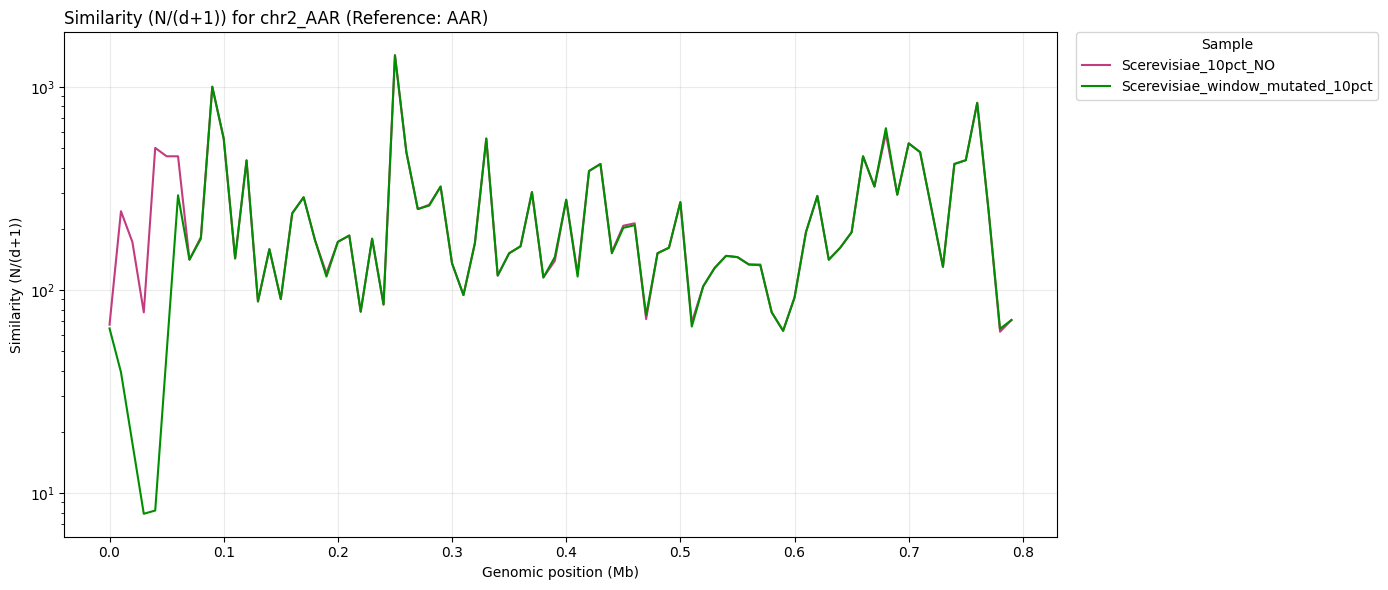

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define SAMPLE_COLORS locally for this example
SAMPLE_COLORS = {
    "Scerevisiae_10pct_NO": "#C33B80",
    "Scerevisiae_window_mutated_10pct": "#008F00",
}

# Usar el DataFrame pre-filtrado para AAR y chr2
df_plot = dfs_chr2_by_reference['AAR'].copy()

# Crear una nueva figura para la gráfica con un tamaño específico
plt.figure(figsize=(14, 6))

# Obtener una lista ordenada de las muestras únicas para graficar
samples_to_plot = sorted(df_plot['sample'].dropna().unique())

# Iterar sobre cada muestra para graficar su línea
for sample in samples_to_plot:
    # Filtrar el DataFrame para la muestra actual y ordenar por posición genómica
    ssub = df_plot[df_plot['sample'] == sample].sort_values('start_mb')
    # Obtener el color asociado a la muestra, si está definido en SAMPLE_COLORS
    color = SAMPLE_COLORS.get(sample, None)
    # Graficar una línea para la "similarity_N_over_dplus1" vs "start_mb"
    sns.lineplot(x='start_mb', y='similarity_N_over_dplus1', data=ssub, label=sample, color=color)

# Establecer el título de la gráfica, alineado a la izquierda
plt.title('Similarity (N/(d+1)) for chr2_AAR (Reference: AAR)', loc='left')
plt.xlabel('Genomic position (Mb)')
plt.ylabel('Similarity (N/(d+1))')
plt.yscale('log')
plt.grid(alpha=0.25)
plt.legend(title='Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
# Ajustar el diseño para evitar que los elementos se superpongan
plt.tight_layout()
# Mostrar la gráfica generada
plt.show()

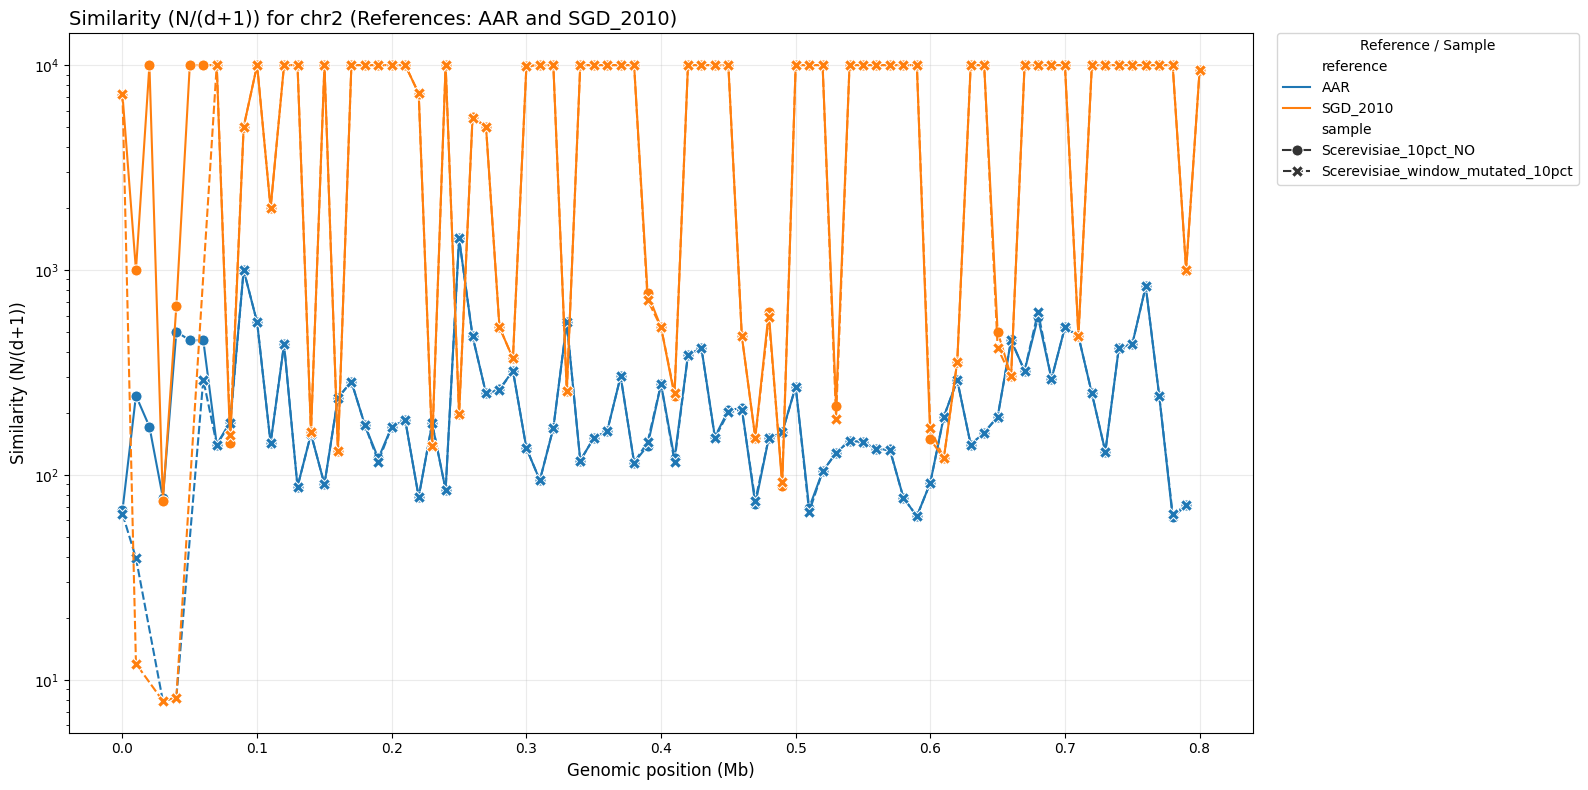

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define SAMPLE_COLORS locally for this example
# Los colores se aplicarán a los nombres de las muestras.
SAMPLE_COLORS = {
    "Scerevisiae_10pct_NO": "#C33B80",
    "Scerevisiae_window_mutated_10pct": "#008F00",
}

# Obtener los DataFrames para las referencias AAR y SGD_2010
df_aar_plot = dfs_chr2_by_reference['AAR'].copy()
df_sgd_plot = dfs_chr2_by_reference['SGD_2010'].copy()

# Concatenar los DataFrames
df_combined_plot = pd.concat([df_aar_plot, df_sgd_plot], ignore_index=True)

# Crear una nueva figura para la gráfica con un tamaño específico
plt.figure(figsize=(16, 8))

# Graficar las líneas usando 'reference' para el color y 'sample' para el estilo de línea
# Esto permite distinguir las muestras por el estilo y las referencias por el color
sns.lineplot(
    x='start_mb',
    y='similarity_N_over_dplus1',
    data=df_combined_plot,
    hue='reference', # Ahora el color distingue las referencias
    style='sample',  # Ahora el estilo de línea distingue las muestras
    linewidth=1.5,
    markers=True, # Añade marcadores a los puntos de datos
    markersize=8 # Ajusta el tamaño de los marcadores
)

plt.title('Similarity (N/(d+1)) for chr2 (References: AAR and SGD_2010)', loc='left', fontsize=14)
plt.xlabel('Genomic position (Mb)', fontsize=12)
plt.ylabel('Similarity (N/(d+1))', fontsize=12)
plt.yscale('log')
plt.grid(alpha=0.25)
plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

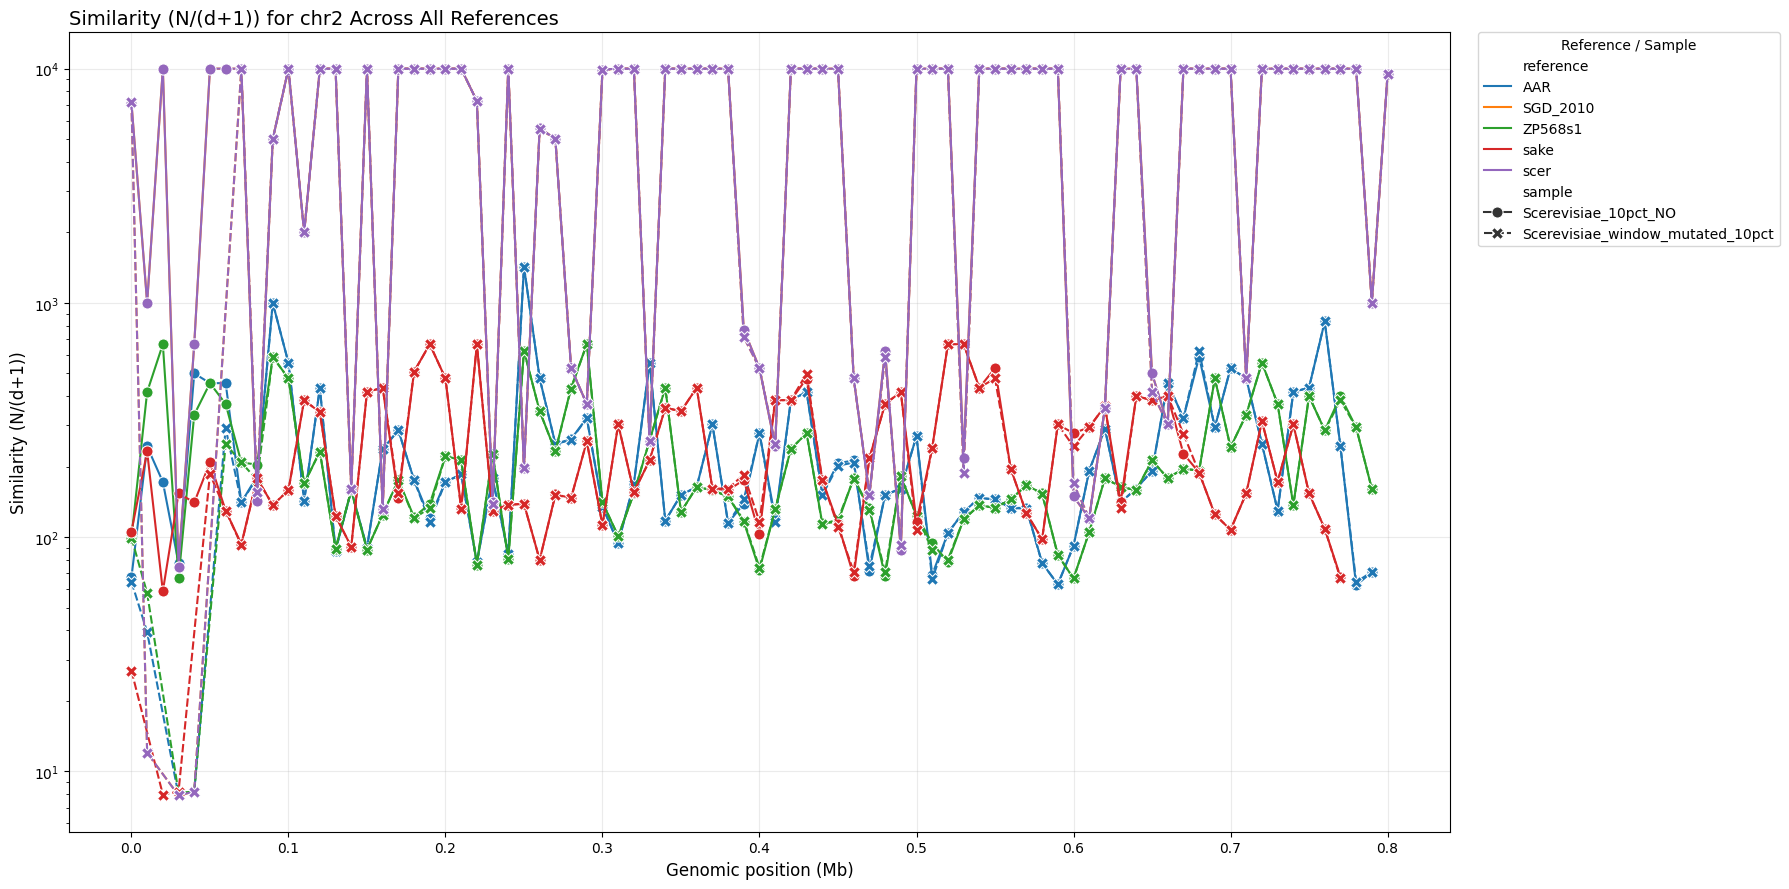

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine all DataFrames from dfs_chr2_by_reference
# into a single DataFrame for plotting all references together.
df_combined_plot_all_refs = pd.concat(
    [df for df in dfs_chr2_by_reference.values()],
    ignore_index=True
)

# Create a new figure for the plot with a specific size
plt.figure(figsize=(18, 9)) # Slightly larger figure for more data

# Plot the lines using 'reference' for color and 'sample' for line style.
# This allows distinguishing samples by line style and references by color.
sns.lineplot(
    x='start_mb',
    y='similarity_N_over_dplus1',
    data=df_combined_plot_all_refs,
    hue='reference', # Color distinguishes references
    style='sample',  # Line style distinguishes samples
    linewidth=1.5,
    markers=True, # Add markers to data points
    markersize=8 # Adjust marker size
)

plt.title('Similarity (N/(d+1)) for chr2 Across All References', loc='left', fontsize=14)
plt.xlabel('Genomic position (Mb)', fontsize=12)
plt.ylabel('Similarity (N/(d+1))', fontsize=12)
plt.yscale('log')
plt.grid(alpha=0.25)
plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

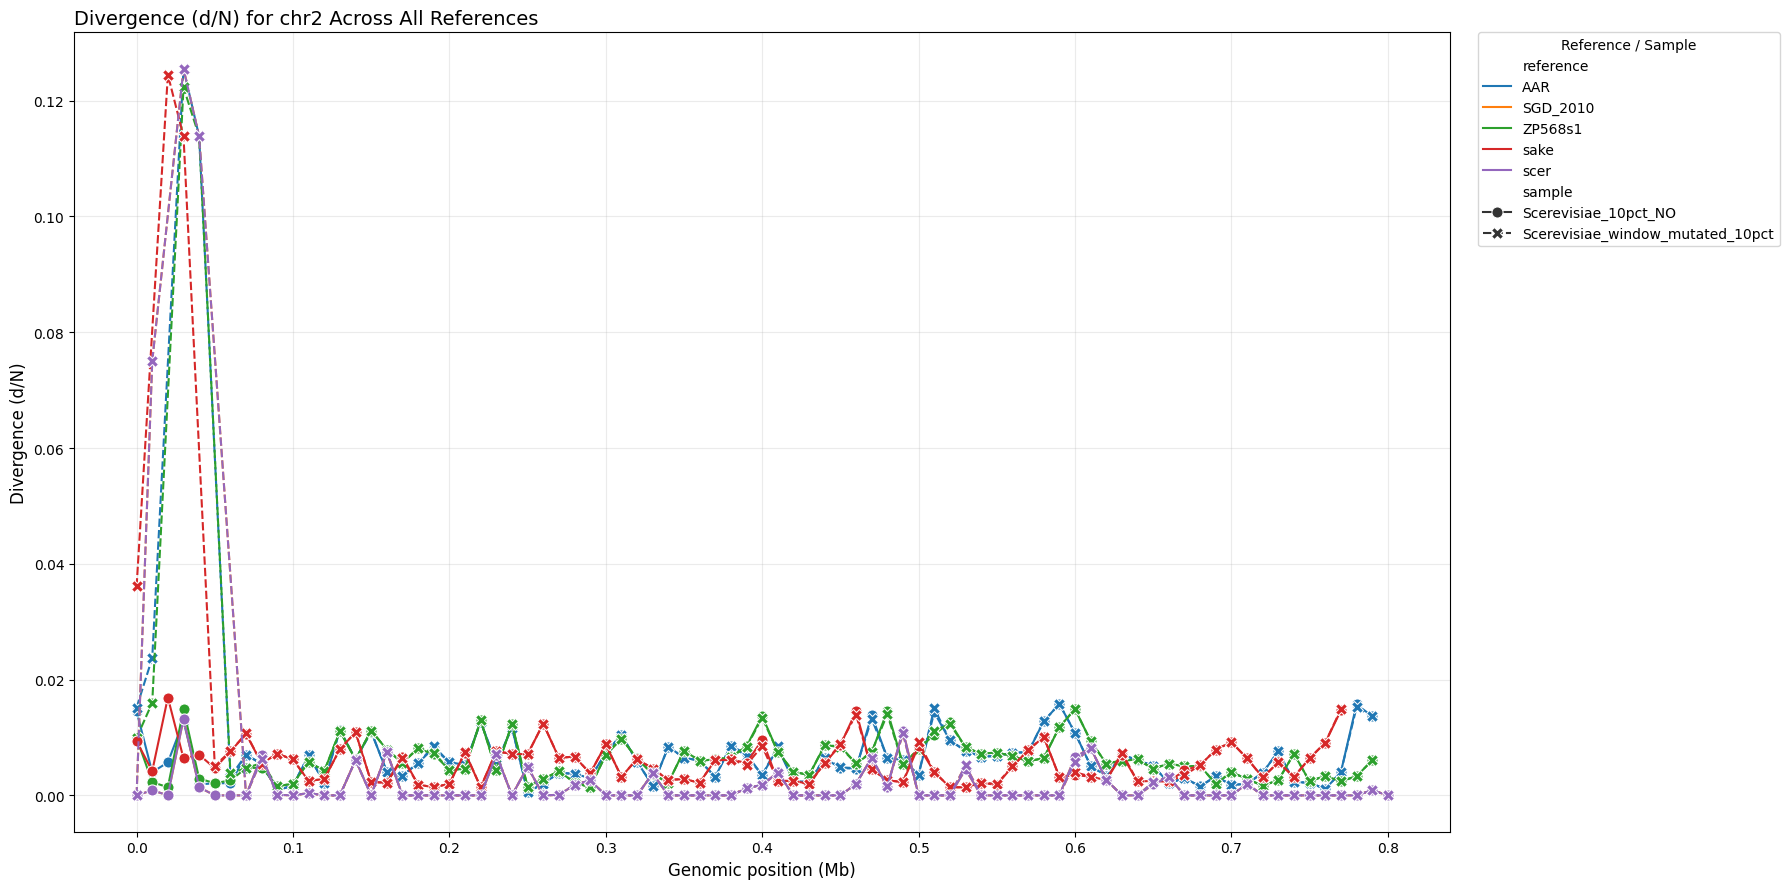

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine all DataFrames from dfs_chr2_by_reference
# into a single DataFrame for plotting all references together.
df_combined_plot_all_refs_divergence = pd.concat(
    [df for df in dfs_chr2_by_reference.values()],
    ignore_index=True
)

# Create a new figure for the plot with a specific size
plt.figure(figsize=(18, 9)) # Slightly larger figure for more data

# Plot the lines using 'reference' for color and 'sample' for line style.
# This allows distinguishing samples by line style and references by color.
sns.lineplot(
    x='start_mb',
    y='divergence_d_over_N', # Change to the new metric
    data=df_combined_plot_all_refs_divergence,
    hue='reference', # Color distinguishes references
    style='sample',  # Line style distinguishes samples
    linewidth=1.5,
    markers=True, # Add markers to data points
    markersize=8 # Adjust marker size
)

plt.title('Divergence (d/N) for chr2 Across All References', loc='left', fontsize=14) # Update title
plt.xlabel('Genomic position (Mb)', fontsize=12)
plt.ylabel('Divergence (d/N)', fontsize=12) # Update y-axis label
# plt.yscale('log') # Log scale might not be appropriate for divergence, remove or adjust if needed
plt.grid(alpha=0.25)
plt.legend(title='Reference / Sample', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()